<a href="https://colab.research.google.com/github/ZivBNS/Introduction-to-Cloud-Computing/blob/main/tagil1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
# @title Default title text
sleepTime = 2 # @param {"type":"integer"}


In [22]:
import time
print(time.ctime())
time.sleep(sleeptime)
print (time.ctime())

Mon Mar 23 09:14:43 2026
Mon Mar 23 09:14:45 2026


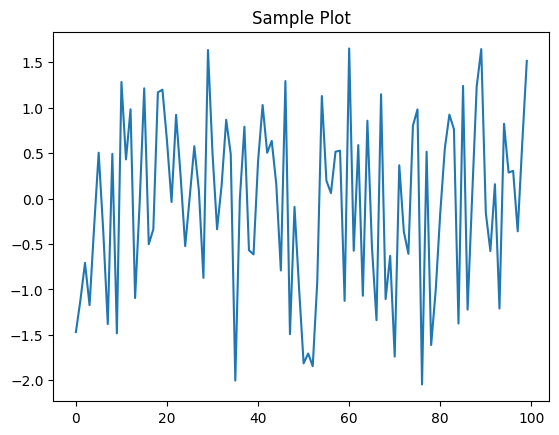

In [23]:
variable_name = ""
import numpy as np
from matplotlib import pyplot as plt

y = np.random.randn(100)
x = [x for x in range(len(y))]

plt.plot(x, y, '-')
plt.fill_between(x, y, 200, where = (y > 195), facecolor='g', alpha=0.6)

plt.title("Sample Plot")
plt.show()


In [26]:
name = "cool" # @param {type:"string"}
print(name)


cool


In [27]:
color = 'blue' #@param ["red", "green", "blue"]
print(color)


blue


In [28]:
#@title Date fields
date_input = '2019-06-03' #@param {type:"date"}
print(date_input)


2019-06-03


In [32]:
#@title Default title text
%%html
<style>
body {
  background-color: #f2bcca;
}
</style>
color = green #@param ["red", "green", "blue"]
print(color)
<svg xmlns="https://www.w3.org/2000/svg" viewBox="0 0 600 400" width="400" height="400">
   <rect x="10" y="00" width="300" height="100" rx="0" style="fill:orange; stroke:black; fill-opacity:1.0" />
   <rect x="10" y="100" width="300" height="100" rx="0" style="fill:white; stroke:black; fill-opacity:1.0;" />
   <rect x="10" y="200" width="300" height="100" rx="0" style="fill:green; stroke:black; fill-opacity:1.0;" />
</svg>


In [35]:
import os
os.chdir("/content/drive/MyDrive/Colab Notebooks")
with open('1.txt', 'r') as file:
    contents = file.read()
    print(contents)


One 
Two
Three



In [37]:
import ipywidgets as widgets
from IPython.display import display
button = widgets.Button(description="Click Me!")
output = widgets.Output()

def on_button_clicked(b):
  # Display the message within the output widget.
  with output:
    with open('/content/drive/My Drive/Colab Notebooks/1.txt', 'r') as file:
      contents = file.read()
      print(contents)

button.on_click(on_button_clicked)
display(button, output)


Button(description='Click Me!', style=ButtonStyle())

Output()

In [47]:
import re
import os
from google.colab import drive
import ipywidgets as widgets
from IPython.display import display, clear_output

file_path = '/content/drive/MyDrive/Colab Notebooks/student.txt'

def load_students(path):
    students = []
    if os.path.exists(path):
        with open(path, 'r', encoding='utf-8') as f:
            for line in f:
                # Regex pattern: Splits by comma but keeps everything inside [] together
                # Pattern: Field1, Field2, Field3, [List of Courses], Field5
                pattern = r"([^,]+),\s*([^,]+),\s*([^,]+),\s*\[(.*?)\]\s*,\s*([^,]+)"
                match = re.search(pattern, line)

                if match:
                    first, last, email, courses_raw, link = match.groups()

                    # Convert the raw string inside brackets into a Python list
                    courses_list = [c.strip() for c in courses_raw.split(',') if c.strip()]

                    students.append({
                        'display_name': f"{first.strip()} {last.strip()}",
                        'first_name': first.strip(),
                        'last_name': last.strip(),
                        'email': email.strip(),
                        'courses': courses_list,
                        'link': link.strip()
                    })
    return students

# Load initial student list
students_list = load_students(file_path)

style = {'description_width': '120px'}
layout = widgets.Layout(width='450px', margin='5px')

student_dropdown = widgets.Dropdown(
    options=[(s['display_name'], i) for i, s in enumerate(students_list)],
    description='Select Student:',
    style=style,
    layout=layout
)

first_name_input = widgets.Text(description='First Name:', style=style, layout=layout)
last_name_input = widgets.Text(description='Last Name:', style=style, layout=layout)
email_input = widgets.Text(description='Braude Email:', style=style, layout=layout)
courses_input = widgets.Text(description='Semester Courses:', style=style, layout=layout)
link_input = widgets.Text(description='Interesting Link:', style=style, layout=layout)
fav_program_input = widgets.Text(description='Favorite Show:', placeholder='Enter show name...', style=style, layout=layout)

update_button = widgets.Button(
    description='Update & Save',
    button_style='success',
    icon='check',
    layout=widgets.Layout(width='200px', height='40px', margin='20px 0 0 120px')
)

output_area = widgets.Output()


def on_student_change(change):
    idx = change['new']
    s = students_list[idx]
    first_name_input.value = s['first_name']
    last_name_input.value = s['last_name']
    email_input.value = s['email']

    # IMPORTANT: Convert list back to string for the Text widget
    courses_input.value = ", ".join(s['courses'])

    link_input.value = s['link']

student_dropdown.observe(on_student_change, names='value')

def on_update_click(b):
    with output_area:
        clear_output()
        # Wrap the courses text back in brackets for the file
        formatted_courses = f"[{courses_input.value}]"

        # Prepare the data line
        new_entry = (f"{first_name_input.value}, {last_name_input.value}, "
                     f"{email_input.value}, {formatted_courses}, "
                     f"{link_input.value}, {fav_program_input.value}\n")

        try:
            with open(file_path, 'a', encoding='utf-8') as f:
                f.write(new_entry)
            print(f"✅ Success! Updated entry for {first_name_input.value} saved to Drive.")
        except Exception as e:
            print(f"❌ Error saving to file: {e}")

update_button.on_click(on_update_click)

if students_list:
    # Set initial values based on the first student
    on_student_change({'new': 0})

form_container = widgets.VBox([
    widgets.HTML("<h2>Student Management Form</h2>"),
    student_dropdown,
    widgets.HTML("<hr>"),
    first_name_input,
    last_name_input,
    email_input,
    courses_input,
    link_input,
    widgets.HTML("<br><b>Additional Details:</b>"),
    fav_program_input,
    update_button,
    output_area
], layout=widgets.Layout(align_items='flex-start', padding='20px', border='1px solid #ccc', border_radius='10px'))

display(form_container)